## Test test

In [1]:
# setup imports
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.models import *
from src.paths import *
from ewatercycle.observation.grdc import get_grdc_data

from scipy.optimize import minimize
import numpy as np

import cma
import seaborn as sns
import pickle
from pathlib import Path


import warnings
warnings.filterwarnings("ignore", category=UserWarning)

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:


results_folder = Path("results_5")
result_files = list(results_folder.glob("result_seed_*.pkl"))

loaded_results = []
for f in result_files:
    with open(f, "rb") as file:
        res = pickle.load(file)
        loaded_results.append(res)

# Example: print best objective per seed
for r in loaded_results:
    print(f"Seed {r['seed']}: best_f = {r['best_f']}, nfev = {r['nfev']}")


Seed 654321: best_f = 0.17191763464028345, nfev = 336
Seed 445566: best_f = 0.19949317983489395, nfev = 336
Seed 111222: best_f = 0.18266575766731064, nfev = 336
Seed 214025: best_f = 0.1774908250283217, nfev = 336
Seed 112233: best_f = 0.17496212376385142, nfev = 336
Seed 987654: best_f = 0.19312110455840456, nfev = 336
Seed 180988: best_f = 0.18076396819507898, nfev = 336
Seed 555666: best_f = 0.17093738634993197, nfev = 336
Seed 123456: best_f = 0.17459049481278965, nfev = 336
Seed 999000: best_f = 0.19603113310254358, nfev = 336
Seed 777888: best_f = 0.17909213433566995, nfev = 336
Seed 333444: best_f = 0.1751420671288759, nfev = 336


In [4]:
best_params_list = []

for run_idx, run in enumerate(loaded_results):
    seed = run['seed']
    history = run['history']
    
    # find the best evaluation by objective value
    best_idx = np.argmin(history['objective'])
    
    best_theta_phys = history['theta_phys'][best_idx]
    best_obj = history['objective'][best_idx]
    best_nse = history['nse'][best_idx]
    best_kge = history['kge'][best_idx]
    best_vol_err = history['vol_err'][best_idx]
    
    row = {
        'seed': seed,
        'best_eval': best_idx + 1,
        'objective': best_obj,
        'nse': best_nse,
        'kge': best_kge,
        'vol_err': best_vol_err
    }
    
    # add each parameter with its proper name
    for i, th in enumerate(best_theta_phys):
        row[parameter_names[i]] = th
    
    best_params_list.append(row)

# create DataFrame
best_params_df = pd.DataFrame(best_params_list)
best_params_df

,seed,best_eval,objective,nse,kge,vol_err,Imax,Ce,Sumax,Beta,Pmax,Tlag,Kf,Ks,FM
0,654321,293,0.171918,0.630029,0.807463,0.007913,3.071465,0.418676,391.970878,0.517435,0.282731,12.344405,0.016368,0.007797,0.163310
1,445566,234,0.199493,0.598174,0.753342,0.012370,0.172047,0.943182,216.764458,0.944472,0.163746,11.867648,0.010492,0.005113,0.753511
2,111222,259,0.182666,0.604927,0.796333,0.007609,21.210294,0.912848,241.462996,0.784030,0.166146,3.559898,0.014930,0.007405,0.135371
3,214025,182,0.177491,0.626687,0.793095,0.008563,14.949804,0.752314,176.396780,0.860738,0.150513,11.316830,0.010002,0.001095,0.227417
4,112233,330,0.174962,0.639353,0.810083,0.024482,3.307732,0.445768,435.074156,0.507541,0.053928,8.578675,0.017573,0.003685,0.126745
5,987654,307,0.193121,0.615278,0.745142,0.003118,12.075565,0.792124,112.167705,0.775480,0.183897,8.094614,0.012597,0.008633,0.126033
6,180988,279,0.180764,0.617970,0.786038,0.004916,8.057864,0.520629,241.155511,0.529037,0.086483,12.839495,0.013819,0.003484,0.145419
7,555666,282,0.170937,0.630740,0.800043,0.000430,22.459392,0.690535,188.080331,0.669292,0.281391,2.097142,0.014930,0.009363,0.135953
8,123456,254,0.174590,0.623010,0.803366,0.006258,12.551151,0.869124,194.691621,0.767942,0.121602,2.990049,0.015812,0.005601,0.114245
9,999000,322,0.196031,0.608890,0.765630,0.020968,8.309573,0.583102,159.311417,0.577138,0.085369,7.255024,0.011975,0.009786,0.176119


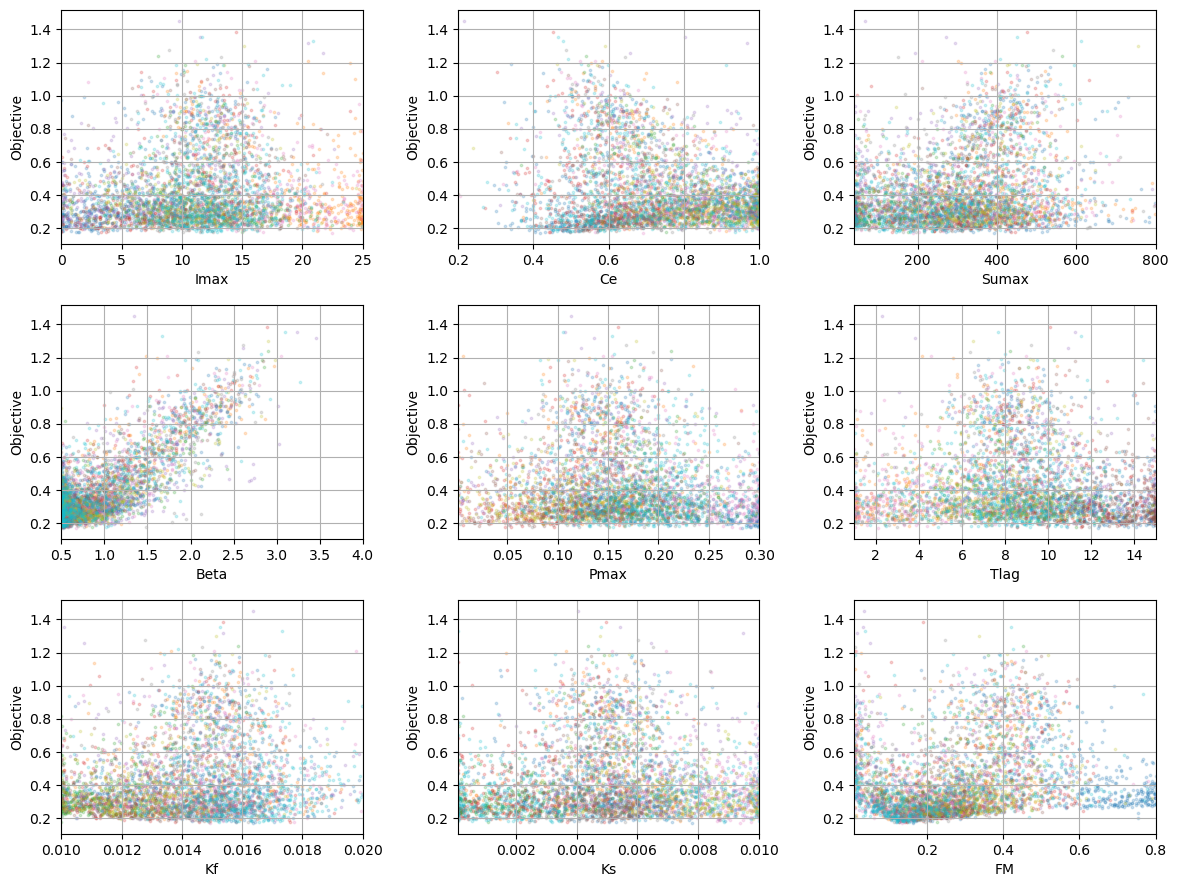

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Suppose you have multiple seeds in `results`:
dfs = []
for seed_idx, res_seed in enumerate(loaded_results):
    hist = res_seed['history']
    df = pd.DataFrame(hist)
    df['seed'] = seed_idx  # add a seed column
    dfs.append(df)

history_df = pd.concat(dfs, ignore_index=True)

n_params = len(p_min)  # 9
seeds = history_df['seed'].unique()  # get all unique seeds
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))  # assign colors

n_cols = 3
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()  # flatten for easy indexing

for i in range(n_params):
    ax = axes[i]
    
    for seed, color in zip(seeds, colors):
        theta_array = np.stack(history_df.loc[history_df['seed']==seed, 'theta_phys'].values)
        obj_array = history_df.loc[history_df['seed']==seed, 'objective'].values
        ax.scatter(theta_array[:, i], obj_array, label=f"Seed {seed}", color=color, alpha=0.2, s=3)
        ax.set_xlabel(parameter_names[i])
    
    ax.set_ylabel("Objective")
    #ax.set_title()
    ax.set_xlim(p_min[i], p_max[i])
    ax.grid(True)

# remove empty axes
for j in range(n_params, len(axes)):
    fig.delaxes(axes[j])


#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


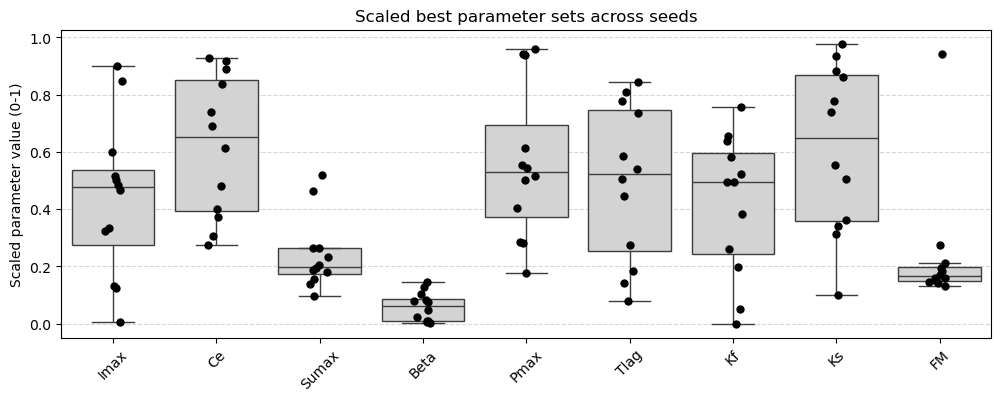

In [6]:
# Parameter columns
param_cols = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","FM"]

# Scale the best parameters
scaled_params_df = pd.DataFrame(scale(best_params_df[param_cols].to_numpy()), 
                                columns=param_cols)


plt.figure(figsize=(12,4))
# sns.boxplot(data=scaled_params_df, color = 'lightgray')
# sns.stripplot(data=scaled_params_df, color='black', jitter=False, size=8)
sns.boxplot(data=scaled_params_df, color='lightgray', fliersize=0)  # light gray boxes, hide default outliers
sns.stripplot(data=scaled_params_df, color='black', jitter=True, size=6, marker='o')  # black dots

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title("Scaled best parameter sets across seeds")
# add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [7]:
rows = []

for run_idx, run in enumerate(loaded_results):
    seed = run['seed']
    history = run['history']
    
    n_eval = len(history['objective'])
    
    for i in range(n_eval):
        row = {
            'seed': seed,
            'eval': i + 1,
            'objective': history['objective'][i],
            'nse': history['nse'][i],
            'kge': history['kge'][i],
            'vol_err': history['vol_err'][i],
        }
        
        # parameters
        for j, th in enumerate(history['theta_phys'][i]):
            row[parameter_names[j]] = th
        
        rows.append(row)

all_results_df = pd.DataFrame(rows)
best_row = all_results_df.loc[all_results_df['objective'].idxmin()]

print(best_row)

seed         555666.000000
eval            282.000000
objective         0.170937
nse               0.630740
kge               0.800043
vol_err           0.000430
Imax             22.459392
Ce                0.690535
Sumax           188.080331
Beta              0.669292
Pmax              0.281391
Tlag              2.097142
Kf                0.014930
Ks                0.009363
FM                0.135953
Name: 2633, dtype: float64


In [8]:
q = 0.02  # best 5%
threshold = all_results_df['objective'].quantile(q)

best_5pct_df = all_results_df[
    all_results_df['objective'] <= threshold
].sort_values('objective')


In [9]:
len(best_5pct_df), len(all_results_df)


(81, 4032)

In [10]:
best_5pct_df['seed'].value_counts()


seed
777888    22
654321    17
123456    10
112233     8
180988     7
555666     6
333444     6
987654     2
214025     1
111222     1
999000     1
Name: count, dtype: int64

In [11]:
# 1. Make a copy of describe
desc_fixed = best_params_df[parameter_names].describe()

# 2. Convert count to int
desc_fixed.loc['count'] = desc_fixed.loc['count'].apply(int)

# 3. Round other stats
desc_fixed.loc[desc_fixed.index != 'count'] = desc_fixed.loc[desc_fixed.index != 'count'].round(3)

# 4. Set index name
desc_fixed.index.name = 'Statistic'

# 5. Rename the problematic row labels (the index)
desc_fixed = desc_fixed.rename(index={
    '25%': 'Q25',
    '50%': 'Median',
    '75%': 'Q75'
})

# 6. Export to LaTeX
latex_table = desc_fixed.to_latex(
    index=True,
    float_format="%.3f",
    caption="Summary statistics of calibrated parameters",
    label="tab:param_summary",
    escape=False  # safe since we removed problematic % signs
)

# 7. Write to file
with open("parameter_summary.tex", "w") as f:
    f.write(latex_table)

print("LaTeX table saved as 'parameter_summary.tex'")


LaTeX table saved as 'parameter_summary.tex'


In [12]:
print(desc_fixed.index)

Index(['count', 'mean', 'std', 'min', 'Q25', 'Median', 'Q75', 'max'], dtype='object', name='Statistic')


In [13]:
best_5pct_df[parameter_names].describe()


,Imax,Ce,Sumax,Beta,Pmax,Tlag,Kf,Ks,FM
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,9.675829,0.600220,250.454247,0.627373,0.179992,9.207149,0.015172,0.004777,0.152924
std,5.954193,0.162439,112.401977,0.183004,0.080799,3.730432,0.001473,0.002780,0.028464
min,0.000124,0.389335,40.387499,0.500042,0.005761,1.021756,0.010002,0.000103,0.106786
25%,4.194242,0.490698,162.542915,0.517578,0.120697,7.255024,0.014497,0.002499,0.133170
50%,10.573756,0.536433,241.390726,0.543719,0.180435,9.588129,0.015194,0.004327,0.147242
75%,13.192952,0.640734,310.922282,0.669292,0.247726,12.344405,0.016304,0.006958,0.167826
max,24.238483,0.996402,526.043923,1.479176,0.299558,14.982234,0.017720,0.009988,0.254256


In [14]:
# Parameter columns
param_cols = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","FM"]

# Extract parameters as array
theta = best_5pct_df[param_cols].to_numpy()

# Apply your scaling
scaled_theta = scale(theta)

# Back to DataFrame
scaled_params_df = pd.DataFrame(
    scaled_theta,
    columns=param_cols
)


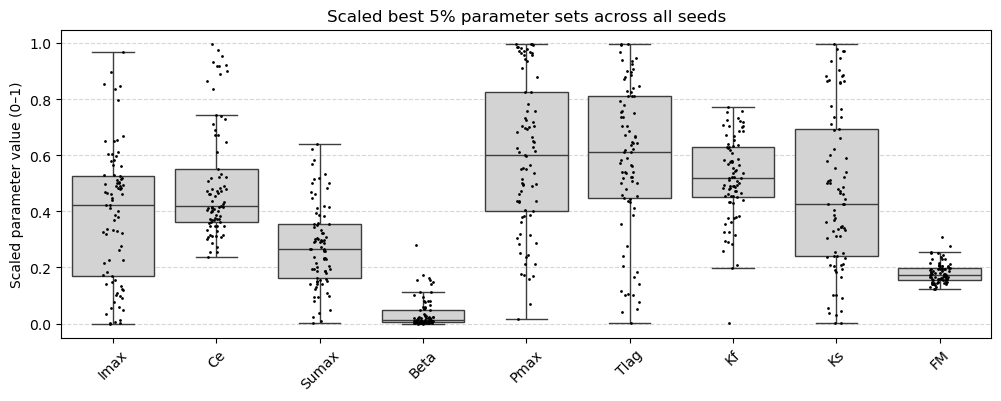

In [15]:
plt.figure(figsize=(12,4))

sns.boxplot(
    data=scaled_params_df,
    color='lightgray',
    fliersize=0
)

sns.stripplot(
    data=scaled_params_df,
    color='black',
    jitter=True,
    size=2,
    marker='o'
)

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0–1)")
plt.title("Scaled best 5% parameter sets across all seeds")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


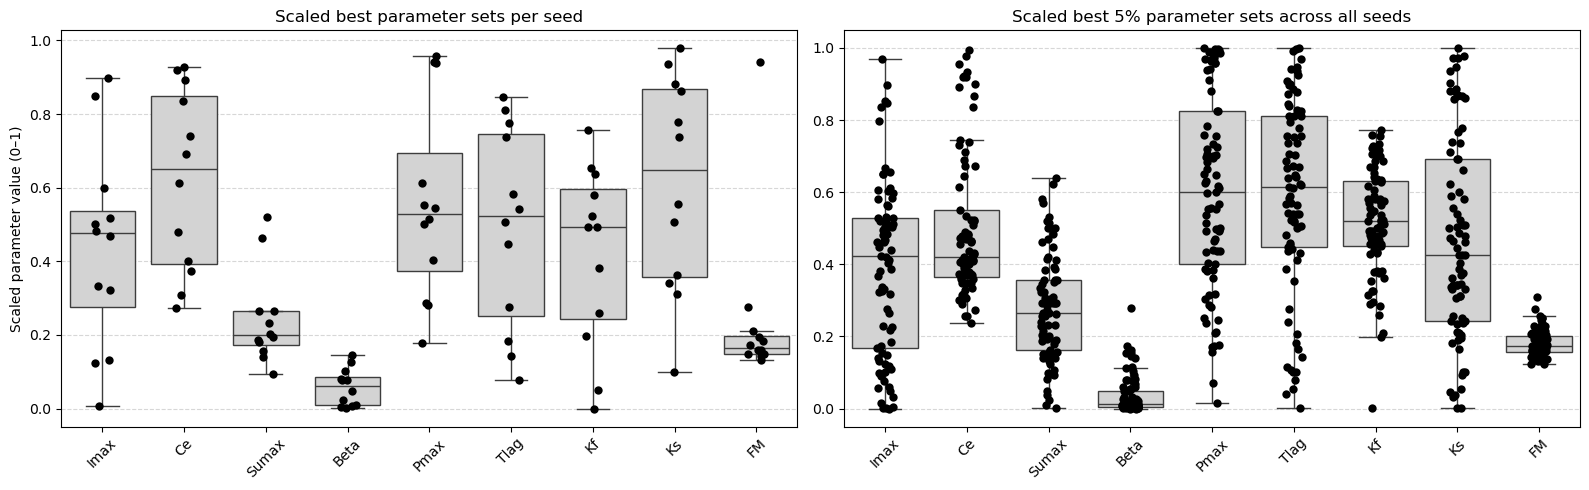

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parameter columns
param_cols = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","FM"]

# Scale both datasets
scaled_best_per_seed = pd.DataFrame(
    scale(best_params_df[param_cols].to_numpy()),
    columns=param_cols
)

scaled_best_5pct = pd.DataFrame(
    scale(best_5pct_df[param_cols].to_numpy()),
    columns=param_cols
)

# Create figure with 2 subplots
plt.figure(figsize=(16,5))

# Left: best per seed
plt.subplot(1,2,1)
sns.boxplot(data=scaled_best_per_seed, color='lightgray', fliersize=0)
sns.stripplot(data=scaled_best_per_seed, color='black', jitter=True, size=6, marker='o')
plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0–1)")
plt.title("Scaled best parameter sets per seed")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Right: top 5%
plt.subplot(1,2,2)
sns.boxplot(data=scaled_best_5pct, color='lightgray', fliersize=0)
sns.stripplot(data=scaled_best_5pct, color='black', jitter=True, size=6, marker='o')
plt.xticks(rotation=45)
plt.ylabel("")
plt.title("Scaled best 5% parameter sets across all seeds")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Parameter columns
param_cols = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","FM"]

# Scale both datasets
scaled_best_per_seed = pd.DataFrame(
    scale(best_params_df[param_cols].to_numpy()),
    columns=param_cols
)
scaled_best_5pct = pd.DataFrame(
    scale(best_5pct_df[param_cols].to_numpy()),
    columns=param_cols
)

# Add a column to identify the group
scaled_best_per_seed['group'] = 'best per seed'
scaled_best_5pct['group'] = f"top {int(100*q)}%"

# Combine both datasets
combined_df = pd.concat([scaled_best_per_seed, scaled_best_5pct], ignore_index=True)

# Melt to long format for seaborn
long_df = combined_df.melt(id_vars='group', value_vars=param_cols, 
                           var_name='parameter', value_name='scaled_value')




In [18]:
long_df['group'].unique()

array(['best per seed', 'top 2%'], dtype=object)

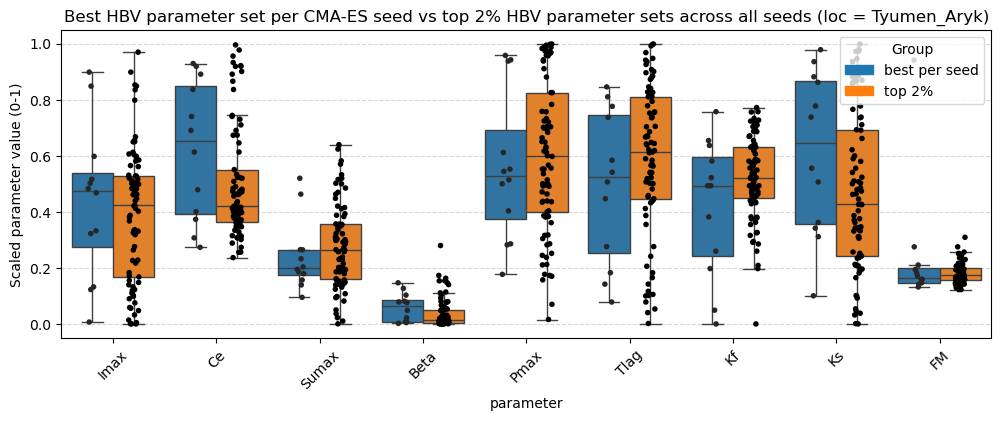

In [19]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))

# palette = {
#     'best per seed': 'darkgray',
#     f"top {int(100*q)}%": 'dimgray'
# }

palette = {
    'best per seed': '#1f77b4',        # blue
    f"top {int(100*q)}%": '#ff7f0e'   # orange
}


sns.boxplot(
    data=long_df,
    x='parameter',
    y='scaled_value',
    hue='group',
    palette=palette,
    fliersize=0
)

sns.stripplot(
    data=long_df,
    x='parameter',
    y='scaled_value',
    hue='group',
    dodge=True,
    jitter=True,
    size=4,
    marker='o',
    alpha=1,
    palette="dark:black",
    legend=False  # avoid duplicate legend entries
)

# 3️⃣ Custom legend from boxplot colors only
handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
plt.legend(handles=handles, title='Group')

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title(f"Best HBV parameter set per CMA-ES seed vs top {int(100*q)}% HBV parameter sets across all seeds (loc = Tyumen_Aryk)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [20]:
loaded_results

[{'seed': 654321,
  'best_f': 0.17191763464028345,
  'best_x': array([0.1228586 , 0.27334508, 0.46311958, 0.00498132, 0.94224426,
         0.81031463, 0.6367726 , 0.77750082, 0.19406339]),
  'nfev': 336,
  'sigma_final': 0.124172310952567,
  'history': {'theta_norm': [array([0.57676188, 0.41152657, 0.51518379, 0.51611545, 0.45547918,
           0.519079  , 0.44783397, 0.41335983, 0.29038838]),
    array([0.42919855, 0.51922823, 0.35447008, 0.52883327, 0.23129447,
           0.57251774, 0.59036982, 0.53880451, 0.5296063 ]),
    array([0.44738771, 0.58791522, 0.55889256, 0.37205078, 0.50616443,
           0.50233399, 0.53620582, 0.38732779, 0.59749375]),
    array([0.50978254, 0.5180425 , 0.47590542, 0.45572504, 0.41851334,
           0.49289197, 0.4191752 , 0.65768756, 0.74012825]),
    array([0.60753282, 0.47720535, 0.55958175, 0.49246971, 0.39235615,
           0.55169148, 0.52603562, 0.33598224, 0.53882064]),
    array([0.45104867, 0.40918026, 0.49399028, 0.34731716, 0.56428427,
    

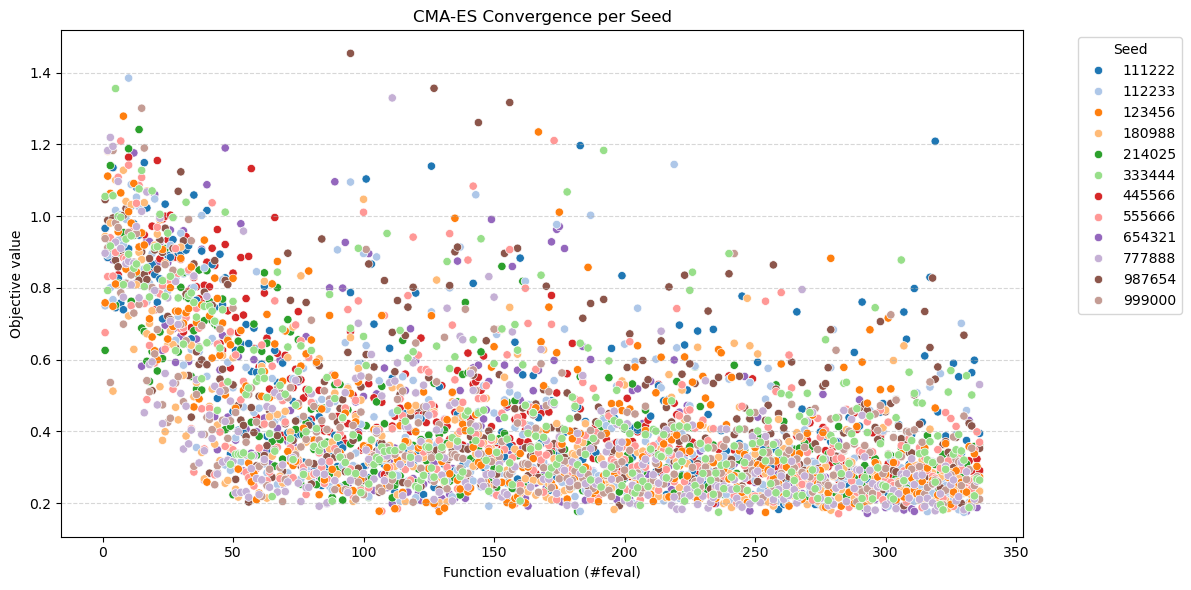

In [21]:
plot_data = []

for run in loaded_results:
    seed = run['seed']
    history = run['history']
    
    fevals = list(range(1, len(history['objective']) + 1))  # #feval
    objectives = history['objective']
    
    for f, obj in zip(fevals, objectives):
        plot_data.append({'seed': seed, 'feval': f, 'objective': obj})

df_plot = pd.DataFrame(plot_data)

# Plot
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_plot,
    x='feval',
    y='objective',
    hue='seed',
    marker='o',
    palette='tab20'  # can use any palette
)

plt.xlabel("Function evaluation (#feval)")
plt.ylabel("Objective value")
plt.title("CMA-ES Convergence per Seed")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Seed', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

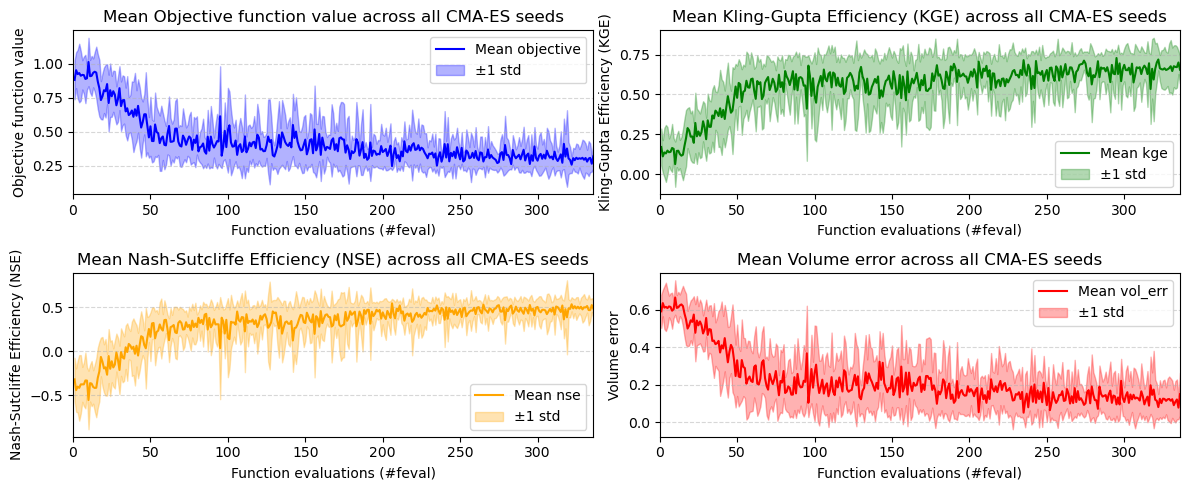

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics = ['objective', 'kge', 'nse', 'vol_err']

# Mapping from metric key to long/descriptive name
metric_names = {
    'objective': 'Objective function value',
    'kge': 'Kling-Gupta Efficiency (KGE)',
    'nse': 'Nash-Sutcliffe Efficiency (NSE)',
    'vol_err': 'Volume error'
}

# Build DataFrame of all seeds and metrics
plot_data = []

for run in loaded_results:
    seed = run['seed']
    history = run['history']
    fevals = np.arange(1, len(history['objective']) + 1)
    
    for f in fevals:
        row = {'seed': seed, 'feval': f}
        for m in metrics:
            row[m] = history[m][f-1]  # f-1 because fevals start at 1
        plot_data.append(row)

df_plot = pd.DataFrame(plot_data)

# Plot mean ± std for each metric
plt.figure(figsize=(12,5))

colors = {'objective':'blue', 'kge':'green', 'nse':'orange', 'vol_err':'red'}

for i, metric in enumerate(metrics, 1):
    plt.subplot(2,2,i)
    
    df_summary = df_plot.groupby('feval')[metric].agg(['mean','std']).reset_index()
    
    plt.plot(df_summary['feval'], df_summary['mean'], color=colors[metric], label=f'Mean {metric}')
    plt.fill_between(
        df_summary['feval'],
        df_summary['mean'] - df_summary['std'],
        df_summary['mean'] + df_summary['std'],
        color=colors[metric],
        alpha=0.3,
        label='±1 std'
    )
    
    plt.xlabel("Function evaluations (#feval)")
    plt.ylabel(metric_names[metric])
    plt.title(f"Mean {metric_names[metric]} across all CMA-ES seeds")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.xlim(0,336)

plt.tight_layout()
plt.show()


